# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV582"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv582')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv582/lv582-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV582,gene_band
0,CENPT,7.277314,16q22.1
1,S1PR3,6.503728,9q22.1
2,GYS1,6.228812,19q13.33
3,HMGCL,6.217355,1p36.11
4,HSD17B10,4.208027,NaN
5,PATL1,4.063119,11q12.1
6,RPL22L1,3.762494,3q26.2
7,GIPC1,3.396838,19p13.12
8,ALG11,3.070153,13q14.3
9,PRPF19,2.810203,11q12.2


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 16:08:47,529 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 16:08:47,530 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP012461, SRP042161, SRP055569, SRP057196, SRP049238, SRP050499, SRP033135, SRP058120, SRP024268, SRP066834, SRP015013, SRP060416, SRP009266, SRP055153, SRP029334, SRP034953, SRP008218, SRP003726, SRP044925, SRP041573, SRP007498, SRP005279, SRP033276, SRP007947, SRP059775, SRP055475, SRP007403, SRP058773, SRP010670, SRP033267, SRP057205, SRP059379, SRP049063, SRP019994, SRP026537, SRP018218, SRP050374, SRP064458, SRP007481, SRP045869, SRP064259, SRP018838, SRP013363, SRP017575, SRP049409, SRP025982, SRP048889, SRP050331, SRP006575, SRP059643, SRP002326, SRP027383, SRP017644, SRP032833, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (52 != 54)
  warnings.warn(


In [12]:
lv_data.shape

(7800, 92)

In [13]:
lv_data.head()

cell type     treatment day  \
project   run                                                   
SRP012461 SRR490216  Mesenchymal Stem Cells    Noninduced  d0   
          SRR490217  Mesenchymal Stem Cells    Noninduced  d0   
          SRR490218  Mesenchymal Stem Cells    Noninduced  d0   
          SRR490219  Mesenchymal Stem Cells    Noninduced  d0   
          SRR490220  Mesenchymal Stem Cells  Adipogenesis  d1   

                    patient code name barcode cell line patient id subtype  \
project   run                                                                
SRP012461 SRR490216         Charlotte  TTTAGG       NaN        NaN     NaN   
          SRR490217         Charlotte  TTTAGG       NaN        NaN     NaN   
          SRR490218         Charlotte  TTTAGG       NaN        NaN     NaN   
          SRR490219         Charlotte  TTTAGG       NaN        NaN     NaN   
          SRR490220         Charlotte  ATTCCA       NaN        NaN     NaN   

                    tissue  age  ... antibodies sample group disease status  \
project   run                    ...                                          
SRP012461 SRR490216    NaN  NaN  ...        NaN          NaN            NaN   
          SRR490217    NaN  NaN  ...        NaN          NaN            NaN   
          SRR490218    NaN  NaN  ...        NaN          NaN            NaN   
          SRR490219    NaN  NaN  ...        NaN          NaN            NaN   
          SRR490220    NaN  NaN  ...        NaN          NaN            NaN   

                    mg/etoh treatment sirna diagnosis history tissue source  \
project   run                                                                 
SRP012461 SRR490216               NaN   NaN       NaN     NaN           NaN   
          SRR490217               NaN   NaN       NaN     NaN           NaN   
          SRR490218               NaN   NaN       NaN     NaN           NaN   
          SRR490219               NaN   NaN       NaN     NaN           NaN   
          SRR490220               NaN   NaN       NaN     NaN           NaN   

                    tissue type     LV582  
project   run                              
SRP012461 SRR490216         NaN -0.011295  
          SRR490217         NaN  0.012259  
          SRR490218         NaN  0.002345  
          SRR490219         NaN  0.024674  
          SRR490220         NaN  0.027498  

[5 rows x 92 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

day                                       0.397230
patient code name                         0.397230
treatment                                 0.379481
barcode                                   0.073320
cell type                                 0.041613
transfection                              0.006513
dicer knockdown                           0.005710
subcellular fraction                      0.005710
cell line/type                            0.005710
dilutions of the malignant b-cell line    0.003680
tnm                                       0.003510
cell state                                0.002742
background cell line                      0.002742
genotype/variation                        0.002742
tamoxifen treatment                       0.002742
antibody manufacturer                     0.002591
antibody catalog #                        0.002591
antibody                                  0.002591
patient id                                0.002365
source                         

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell type         0.041613
cell line/type    0.005710
tissue            0.000798
cell line         0.000573
tissue type       0.000209
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell type",
    "cell line/type",
    "tissue",
    "cell line",
    "tissue type",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell type  \
project   run                                                             
SRP012461 SRR490465                                         Fibroblasts   
          SRR490467                                         Fibroblasts   
          SRR490464                                         Fibroblasts   
          SRR490466                                         Fibroblasts   
SRP042161 SRR1294983                                       Glioblastoma   
SRP055569 SRR1821358                             U87 human glioma cells   
SRP012461 SRR490308                              Mesenchymal Stem Cells   
SRP057196 SRR1974774                                        endothelial   
SRP055569 SRR2019214  mixture of U87 human glioma cells and WI-38 hu...   
          SRR1821437  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974644                                        endothelial   
SRP055569 SRR1821388                             U87 human glioma cells   
          SRR2018981  mixture of U87 human glioma cells and MCF10a h...   
SRP042161 SRR1295010                                       Glioblastoma   
SRP049238 SRR1622981                             primary human myoblast   
SRP050499 SRR2013717                                                NaN   
SRP055569 SRR1821422  mixture of U87 human glioma cells and MCF10a h...   
          SRR1821627                   MCF10a human breast cancer cells   
SRP033135 SRR1033095             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR2019235  mixture of U87 human glioma cells and WI-38 hu...   
SRP058120 SRR2014612                                                NaN   
SRP055569 SRR1821539  mixture of U87 human glioma cells and MCF10a h...   
SRP024268 SRR886379                                                 NaN   
SRP055569 SRR1821592  mixture of U87 human glioma cells and MCF10a h...   
          SRR2018971  mixture of U87 human glioma cells and MCF10a h...   

                            cell line/type        tissue cell line  \
project   run                                                        
SRP012461 SRR490465                    NaN           NaN       NaN   
          SRR490467                    NaN           NaN       NaN   
          SRR490464                    NaN           NaN       NaN   
          SRR490466                    NaN           NaN       NaN   
SRP042161 SRR1294983                   NaN           NaN       NaN   
SRP055569 SRR1821358                   NaN           NaN       NaN   
SRP012461 SRR490308                    NaN           NaN       NaN   
SRP057196 SRR1974774                   NaN        cortex       NaN   
SRP055569 SRR2019214                   NaN           NaN       NaN   
          SRR1821437                   NaN           NaN       NaN   
SRP057196 SRR1974644                   NaN        cortex       NaN   
SRP055569 SRR1821388                   NaN           NaN       NaN   
          SRR2018981                   NaN           NaN       NaN   
SRP042161 SRR1295010                   NaN           NaN       NaN   
SRP049238 SRR1622981                   NaN           NaN       NaN   
SRP050499 SRR2013717                   NaN           NaN       NaN   
SRP055569 SRR1821422                   NaN           NaN       NaN   
          SRR1821627                   NaN           NaN       NaN   
SRP033135 SRR1033095                   NaN           NaN       NaN   
SRP055569 SRR2019235                   NaN           NaN       NaN   
SRP058120 SRR2014612  HBL melanocyte cells           NaN       NaN   
SRP055569 SRR1821539                   NaN           NaN       NaN   
SRP024268 SRR886379                    NaN  renal pelvis       NaN   
SRP055569 SRR1821592                   NaN           NaN       NaN   
          SRR2018971                   NaN           NaN       NaN   

                     tissue type      LV582  
project   run                                
SRP012461 SRR490465          NaN  10.428776  
       

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

,,cell type,cell line/type,tissue,cell line,tissue type,LV582
project,run,,,,,,
SRP066834,SRR2967465,NaN,NaN,Microdissected cortical-like ventricle from ce...,NaN,NaN,0.211392
SRP055569,SRR1821366,U87 human glioma cells,NaN,NaN,NaN,NaN,0.209883
SRP058120,SRR2014613,NaN,HBL melanocyte cells,NaN,NaN,NaN,0.208517
SRP049238,SRR1622980,primary human myoblast,NaN,NaN,NaN,NaN,0.207186
SRP033135,SRR1032949,Human Skeletal Muscle Myoblasts (HSMM),NaN,NaN,NaN,NaN,0.198661
SRP015013,SRR546556,NaN,NaN,NaN,HEK293,NaN,0.193579
SRP055569,SRR1821506,mixture of U87 human glioma cells and MCF10a h...,NaN,NaN,NaN,NaN,0.192714
SRP049238,SRR1622982,primary human myoblast,NaN,NaN,NaN,NaN,0.186627
SRP050499,SRR2013706,NaN,NaN,NaN,NaN,NaN,0.180526


Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "cell type",
    "cell line/type",
    "tissue",
    "cell line",
    "tissue type",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

cell type  \
project   run                                                             
SRP012461 SRR490465                                         Fibroblasts   
          SRR490467                                         Fibroblasts   
          SRR490464                                         Fibroblasts   
          SRR490466                                         Fibroblasts   
SRP042161 SRR1294983                                       Glioblastoma   
SRP055569 SRR1821358                             U87 human glioma cells   
SRP012461 SRR490308                              Mesenchymal Stem Cells   
SRP057196 SRR1974774                                        endothelial   
SRP055569 SRR2019214  mixture of U87 human glioma cells and WI-38 hu...   
          SRR1821437  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974644                                        endothelial   
SRP055569 SRR1821388                             U87 human glioma cells   
          SRR2018981  mixture of U87 human glioma cells and MCF10a h...   
SRP042161 SRR1295010                                       Glioblastoma   
SRP049238 SRR1622981                             primary human myoblast   
SRP050499 SRR2013717                                    NOT CATEGORIZED   
SRP055569 SRR1821422  mixture of U87 human glioma cells and MCF10a h...   
          SRR1821627                   MCF10a human breast cancer cells   
SRP033135 SRR1033095             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR2019235  mixture of U87 human glioma cells and WI-38 hu...   

                          LV582  
project   run                    
SRP012461 SRR490465   10.428776  
          SRR490467    5.883966  
          SRR490464    2.645752  
          SRR490466    1.742241  
SRP042161 SRR1294983   0.984727  
SRP055569 SRR1821358   0.460876  
SRP012461 SRR490308    0.431175  
SRP057196 SRR1974774   0.383687  
SRP055569 SRR2019214   0.357663  
          SRR1821437   0.357205  
SRP057196 SRR1974644   0.338679  
SRP055569 SRR1821388   0.312313  
          SRR2018981   0.299213  
SRP042161 SRR1295010   0.298313  
SRP049238 SRR1622981   0.295403  
SRP050499 SRR2013717   0.282266  
SRP055569 SRR1821422   0.280586  
          SRR1821627   0.270909  
SRP033135 SRR1033095   0.265581  
SRP055569 SRR2019235   0.263113

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['Fibroblasts',
 'Glioblastoma',
 'U87 human glioma cells',
 'Mesenchymal Stem Cells',
 'endothelial']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

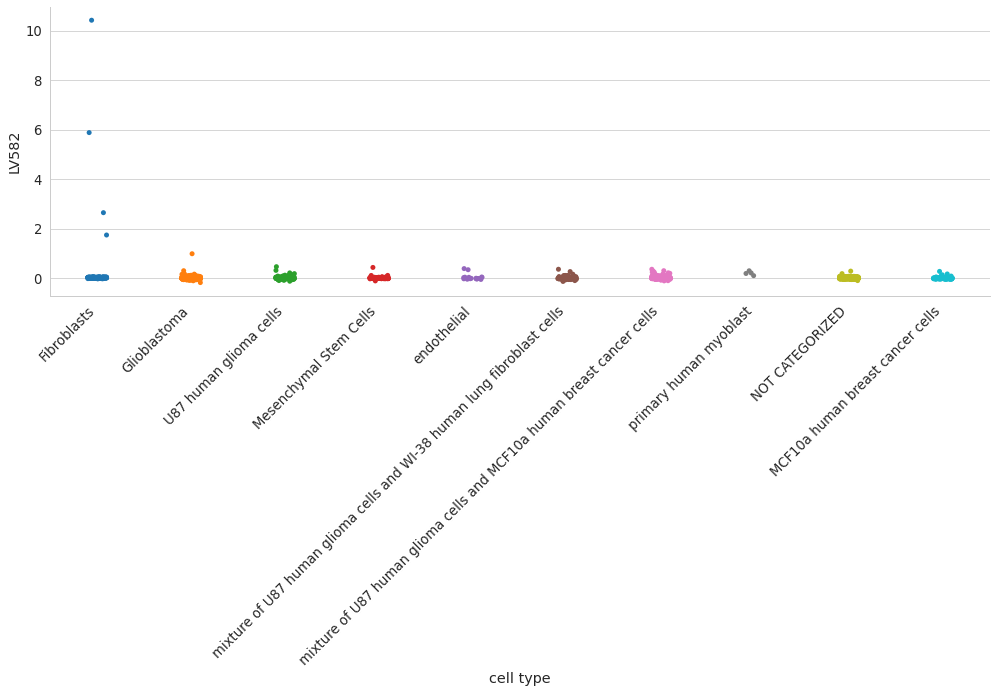

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Mesenc")
    ]
    display(_tmp.head(20))

cell type     LV582
project   run                                        
SRP012461 SRR490308  Mesenchymal Stem Cells  0.431175
          SRR490311  Mesenchymal Stem Cells  0.109218
          SRR490229  Mesenchymal Stem Cells  0.106094
          SRR490280  Mesenchymal Stem Cells  0.060764
          SRR490231  Mesenchymal Stem Cells  0.055113
          SRR490226  Mesenchymal Stem Cells  0.047083
          SRR490245  Mesenchymal Stem Cells  0.038019
          SRR490327  Mesenchymal Stem Cells  0.035258
          SRR490305  Mesenchymal Stem Cells  0.033120
          SRR490338  Mesenchymal Stem Cells  0.032719
          SRR490336  Mesenchymal Stem Cells  0.031067
          SRR490337  Mesenchymal Stem Cells  0.030776
          SRR490284  Mesenchymal Stem Cells  0.030576
          SRR490331  Mesenchymal Stem Cells  0.030554
          SRR490339  Mesenchymal Stem Cells  0.028162
          SRR490333  Mesenchymal Stem Cells  0.027978
          SRR490220  Mesenchymal Stem Cells  0.027498
          SRR490296  Mesenchymal Stem Cells  0.027087
          SRR490328  Mesenchymal Stem Cells  0.027043
          SRR490290  Mesenchymal Stem Cells  0.026657

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP012461, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP012461"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell type       treatment day  \
project   run                                                     
SRP012461 SRR490465             Fibroblasts    Osteogenesis  d3   
          SRR490467             Fibroblasts    Osteogenesis  d3   
          SRR490464             Fibroblasts    Osteogenesis  d3   
          SRR490466             Fibroblasts    Osteogenesis  d3   
          SRR490308  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490311  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490229  Mesenchymal Stem Cells    Adipogenesis  d3   
          SRR490280  Mesenchymal Stem Cells    Osteogenesis  d1   
          SRR490231  Mesenchymal Stem Cells    Adipogenesis  d3   
          SRR490425             Fibroblasts    Adipogenesis  d7   
          SRR490456             Fibroblasts      Noninduced  d0   
          SRR490226  Mesenchymal Stem Cells    Adipogenesis  d2   
          SRR490449             Fibroblasts    Adipogenesis  d5   
          SRR490459             Fibroblasts      Noninduced  d0   
          SRR490452             Fibroblasts    Adipogenesis  d7   
          SRR490458             Fibroblasts      Noninduced  d0   
          SRR490514             Fibroblasts    Osteogenesis  d7   
          SRR490446             Fibroblasts    Adipogenesis  d4   
          SRR490571             Fibroblasts  Chondrogenesis  d5   
          SRR490511             Fibroblasts    Osteogenesis  d6   
          SRR490522             Fibroblasts  Chondrogenesis  d1   
          SRR490512             Fibroblasts    Osteogenesis  d7   
          SRR490427             Fibroblasts    Adipogenesis  d7   
          SRR490523             Fibroblasts  Chondrogenesis  d1   
          SRR490421             Fibroblasts    Adipogenesis  d6   
          SRR490517             Fibroblasts      Noninduced  d0   
          SRR490429             Fibroblasts      Noninduced  d0   
          SRR490509             Fibroblasts    Osteogenesis  d6   
          SRR490245  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490510             Fibroblasts    Osteogenesis  d6   
          SRR490445             Fibroblasts    Adipogenesis  d4   
          SRR490444             Fibroblasts    Adipogenesis  d4   
          SRR490327  Mesenchymal Stem Cells    Osteogenesis  d4   
          SRR490515             Fibroblasts    Osteogenesis  d7   
          SRR490447             Fibroblasts    Adipogenesis  d4   
          SRR490520             Fibroblasts  Chondrogenesis  d1   
          SRR490428             Fibroblasts      Noninduced  d0   
          SRR490418             Fibroblasts    Adipogenesis  d5   
          SRR490305  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490419             Fibroblasts    Adipogenesis  d5   
          SRR490485             Fibroblasts      Noninduced  d0   
          SRR490338  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490513             Fibroblasts    Osteogenesis  d7   
          SRR490499             Fibroblasts    Osteogenesis  d3   
          SRR490541             Fibroblasts  Chondrogenesis  d6   
          SRR490491             Fibroblasts    Osteogenesis  d1   
          SRR490497             Fibroblasts    Osteogenesis  d3   
          SRR490336  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490508             Fibroblasts    Osteogenesis  d6   
          SRR490337  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490519             Fibroblasts      Noninduced  d0   
          SRR490524             Fibroblasts  Chondrogenesis  d2   
          SRR490284  Mesenchymal Stem Cells    Osteogenesis  d2   
          SRR490457             Fibroblasts      Noninduced  d0   
          SRR490331  Mesenchymal Stem Cells    Osteogenesis  d5   
          SRR490516             Fibroblasts      Noninduced  d0   
          SRR490417             Fibroblasts    Adipogenesis  d5   
          SRR490498             Fibroblasts    Osteogenesis  d3   
          SRR4

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.